IMPORTING ALL THE LIBRARIES


In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
import seaborn as sns



READING THE DATASET

In [2]:
# load the dataset
data = pd.read_csv(r'C:\Users\PRUSHOTHAM\OneDrive\Desktop/Breast Cancer METABRIC.csv')

In [3]:
data.head()


,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,1.0,Positve,...,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,...,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,No,151.28,Recurred,Female,NaN,15.0,2.0,Died of Disease
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1.0,Positve,...,Living,Positive,Yes,162.76,Not Recurred,Female,NaN,25.0,2.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


In [4]:
data.shape

(2509, 34)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2509 entries, 0 to 2508
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Patient ID                      2509 non-null   object 
 1   Age at Diagnosis                2498 non-null   float64
 2   Type of Breast Surgery          1955 non-null   object 
 3   Cancer Type                     2509 non-null   object 
 4   Cancer Type Detailed            2509 non-null   object 
 5   Cellularity                     1917 non-null   object 
 6   Chemotherapy                    1980 non-null   object 
 7   Pam50 + Claudin-low subtype     1980 non-null   object 
 8   Cohort                          2498 non-null   float64
 9   ER status measured by IHC       2426 non-null   object 
 10  ER Status                       2469 non-null   object 
 11  Neoplasm Histologic Grade       2388 non-null   float64
 12  HER2 status measured by SNP6    19

In [6]:
data.isnull().sum()

Patient ID                          0
Age at Diagnosis                   11
Type of Breast Surgery            554
Cancer Type                         0
Cancer Type Detailed                0
Cellularity                       592
Chemotherapy                      529
Pam50 + Claudin-low subtype       529
Cohort                             11
ER status measured by IHC          83
ER Status                          40
Neoplasm Histologic Grade         121
HER2 status measured by SNP6      529
HER2 Status                       529
Tumor Other Histologic Subtype    135
Hormone Therapy                   529
Inferred Menopausal State         529
Integrative Cluster               529
Primary Tumor Laterality          639
Lymph nodes examined positive     266
Mutation Count                    152
Nottingham prognostic index       222
Oncotree Code                       0
Overall Survival (Months)         528
Overall Survival Status           528
PR Status                         529
Radio Therap

In [7]:
data=data.drop(columns=['Patient ID'])

In [8]:
data.columns

Index(['Age at Diagnosis', 'Type of Breast Surgery', 'Cancer Type',
       'Cancer Type Detailed', 'Cellularity', 'Chemotherapy',
       'Pam50 + Claudin-low subtype', 'Cohort', 'ER status measured by IHC',
       'ER Status', 'Neoplasm Histologic Grade',
       'HER2 status measured by SNP6', 'HER2 Status',
       'Tumor Other Histologic Subtype', 'Hormone Therapy',
       'Inferred Menopausal State', 'Integrative Cluster',
       'Primary Tumor Laterality', 'Lymph nodes examined positive',
       'Mutation Count', 'Nottingham prognostic index', 'Oncotree Code',
       'Overall Survival (Months)', 'Overall Survival Status', 'PR Status',
       'Radio Therapy', 'Relapse Free Status (Months)', 'Relapse Free Status',
       'Sex', '3-Gene classifier subtype', 'Tumor Size', 'Tumor Stage',
       'Patient's Vital Status'],
      dtype='object')

HANDLING THE MISSING VALUES

In [9]:
#SINCE WE HAVE THE MISSING VALUES IN THE TARGET VARIABLE WE ARE GOING TO REMOVE THAT
data["Patient's Vital Status"].isnull().sum()

np.int64(529)

In [10]:
data= data.dropna(subset=["Patient's Vital Status"])

In [11]:
data.shape

(1980, 33)

In [12]:
data.isnull().sum()

Age at Diagnosis                    0
Type of Breast Surgery             26
Cancer Type                         0
Cancer Type Detailed                0
Cellularity                        64
Chemotherapy                        1
Pam50 + Claudin-low subtype         1
Cohort                              0
ER status measured by IHC          43
ER Status                           0
Neoplasm Histologic Grade          88
HER2 status measured by SNP6        1
HER2 Status                         1
Tumor Other Histologic Subtype     44
Hormone Therapy                     1
Inferred Menopausal State           1
Integrative Cluster                 1
Primary Tumor Laterality          111
Lymph nodes examined positive      76
Mutation Count                    121
Nottingham prognostic index         1
Oncotree Code                       0
Overall Survival (Months)           0
Overall Survival Status             0
PR Status                           1
Radio Therapy                       1
Relapse Free

SPLITTING OF NUMARICAL FEATURES AND CATEGORICAL FEATURES

In [13]:
# sepearating numarical and categorical colums
numarical_cols = data.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

FILLING THE MISSING VALUES

In [14]:
print(numarical_cols)

['Age at Diagnosis', 'Cohort', 'Neoplasm Histologic Grade', 'Lymph nodes examined positive', 'Mutation Count', 'Nottingham prognostic index', 'Overall Survival (Months)', 'Relapse Free Status (Months)', 'Tumor Size', 'Tumor Stage']


In [15]:
#understanding the numarical columns 
num_cols = data.select_dtypes(include=["int64", "float64"]).columns
print("Tumor Stage" in num_cols)




True


In [16]:
# seleting only tumor stage column for imputation
temp_num_data = data[num_cols].copy()

In [17]:
# applying knn imputer 
knn_imputer = KNNImputer(n_neighbors=5)
temp_num_data_imputed = knn_imputer.fit_transform(temp_num_data)


In [18]:
#converting the imputed arry to dataframe
temp_num_data_imputed = pd.DataFrame(
    temp_num_data_imputed,
    columns=num_cols,
    index=data.index
)


In [19]:
#replacing the  imputed values back to original data
data["Tumor Stage"] = temp_num_data_imputed["Tumor Stage"]


In [20]:
data["Tumor Stage"].isnull().sum()


np.int64(0)

In [21]:
# checking missing values after imputation
data.isnull().sum().sort_values(ascending=False)


3-Gene classifier subtype         217
Mutation Count                    121
Primary Tumor Laterality          111
Neoplasm Histologic Grade          88
Lymph nodes examined positive      76
Cellularity                        64
Tumor Other Histologic Subtype     44
ER status measured by IHC          43
Type of Breast Surgery             26
Tumor Size                         26
HER2 status measured by SNP6        1
Integrative Cluster                 1
Hormone Therapy                     1
Inferred Menopausal State           1
HER2 Status                         1
Pam50 + Claudin-low subtype         1
Chemotherapy                        1
PR Status                           1
Radio Therapy                       1
Nottingham prognostic index         1
Age at Diagnosis                    0
ER Status                           0
Cancer Type                         0
Cancer Type Detailed                0
Cohort                              0
Overall Survival Status             0
Overall Surv

In [22]:
#removing the "Tumoir stage" column in numarical columns
num_cols_without_stage = num_cols.drop("Tumor Stage", errors="ignore")


In [23]:
# imputing the remaining numarical coloums with median
for col in num_cols_without_stage:
    data[col].fillna(data[col].median(), inplace=True)


C:\Users\PRUSHOTHAM\AppData\Local\Temp\ipykernel_23672\700327799.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)


In [24]:
#checking the numarical columns missing values
data.isnull().sum()

Age at Diagnosis                    0
Type of Breast Surgery             26
Cancer Type                         0
Cancer Type Detailed                0
Cellularity                        64
Chemotherapy                        1
Pam50 + Claudin-low subtype         1
Cohort                              0
ER status measured by IHC          43
ER Status                           0
Neoplasm Histologic Grade           0
HER2 status measured by SNP6        1
HER2 Status                         1
Tumor Other Histologic Subtype     44
Hormone Therapy                     1
Inferred Menopausal State           1
Integrative Cluster                 1
Primary Tumor Laterality          111
Lymph nodes examined positive       0
Mutation Count                      0
Nottingham prognostic index         0
Oncotree Code                       0
Overall Survival (Months)           0
Overall Survival Status             0
PR Status                           1
Radio Therapy                       1
Relapse Free

In [25]:
#imputing the categorical columns with mode
for col in categorical_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)


C:\Users\PRUSHOTHAM\AppData\Local\Temp\ipykernel_23672\2121145901.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [26]:
# checking missing values after imputation
data.isnull().sum().sort_values(ascending=False)


Age at Diagnosis                  0
Type of Breast Surgery            0
Cancer Type                       0
Cancer Type Detailed              0
Cellularity                       0
Chemotherapy                      0
Pam50 + Claudin-low subtype       0
Cohort                            0
ER status measured by IHC         0
ER Status                         0
Neoplasm Histologic Grade         0
HER2 status measured by SNP6      0
HER2 Status                       0
Tumor Other Histologic Subtype    0
Hormone Therapy                   0
Inferred Menopausal State         0
Integrative Cluster               0
Primary Tumor Laterality          0
Lymph nodes examined positive     0
Mutation Count                    0
Nottingham prognostic index       0
Oncotree Code                     0
Overall Survival (Months)         0
Overall Survival Status           0
PR Status                         0
Radio Therapy                     0
Relapse Free Status (Months)      0
Relapse Free Status         

In [27]:
# getting the statistical summary of the data
data.describe(include='all')

,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,ER Status,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
count,1980.000000,1980,1980,1980,1980,1980,1980,1980.000000,1980,1980,...,1980,1980,1980,1980.000000,1980,1980,1980,1980.000000,1980.000000,1980
unique,NaN,2,2,8,3,2,7,NaN,2,2,...,2,2,2,NaN,2,1,4,NaN,NaN,3
top,NaN,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,NaN,Positve,Positive,...,Deceased,Positive,Yes,NaN,Not Recurred,Female,ER+/HER2- Low Prolif,NaN,NaN,Living
freq,NaN,1196,1977,1537,1029,1568,700,NaN,1541,1506,...,1143,1040,1173,NaN,1177,1980,857,NaN,NaN,837
mean,61.088237,NaN,NaN,NaN,NaN,NaN,NaN,2.619192,NaN,NaN,...,NaN,NaN,NaN,110.001389,NaN,NaN,NaN,26.238263,1.737475,NaN
std,12.952862,NaN,NaN,NaN,NaN,NaN,NaN,1.232635,NaN,NaN,...,NaN,NaN,NaN,76.262071,NaN,NaN,NaN,15.284870,0.591219,NaN
min,21.930000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,...,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,1.000000,0.000000,NaN
25%,51.420000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,...,NaN,NaN,NaN,41.732500,NaN,NaN,NaN,17.000000,1.000000,NaN
50%,61.825000,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,...,NaN,NaN,NaN,100.720000,NaN,NaN,NaN,23.000000,2.000000,NaN
75%,70.602500,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,...,NaN,NaN,NaN,167.472500,NaN,NaN,NaN,30.000000,2.000000,NaN


EDA ANALYSIS

In [28]:
num_cols_for_plot = data.select_dtypes(include=["int64", "float64"]).columns.drop("Tumor Stage")


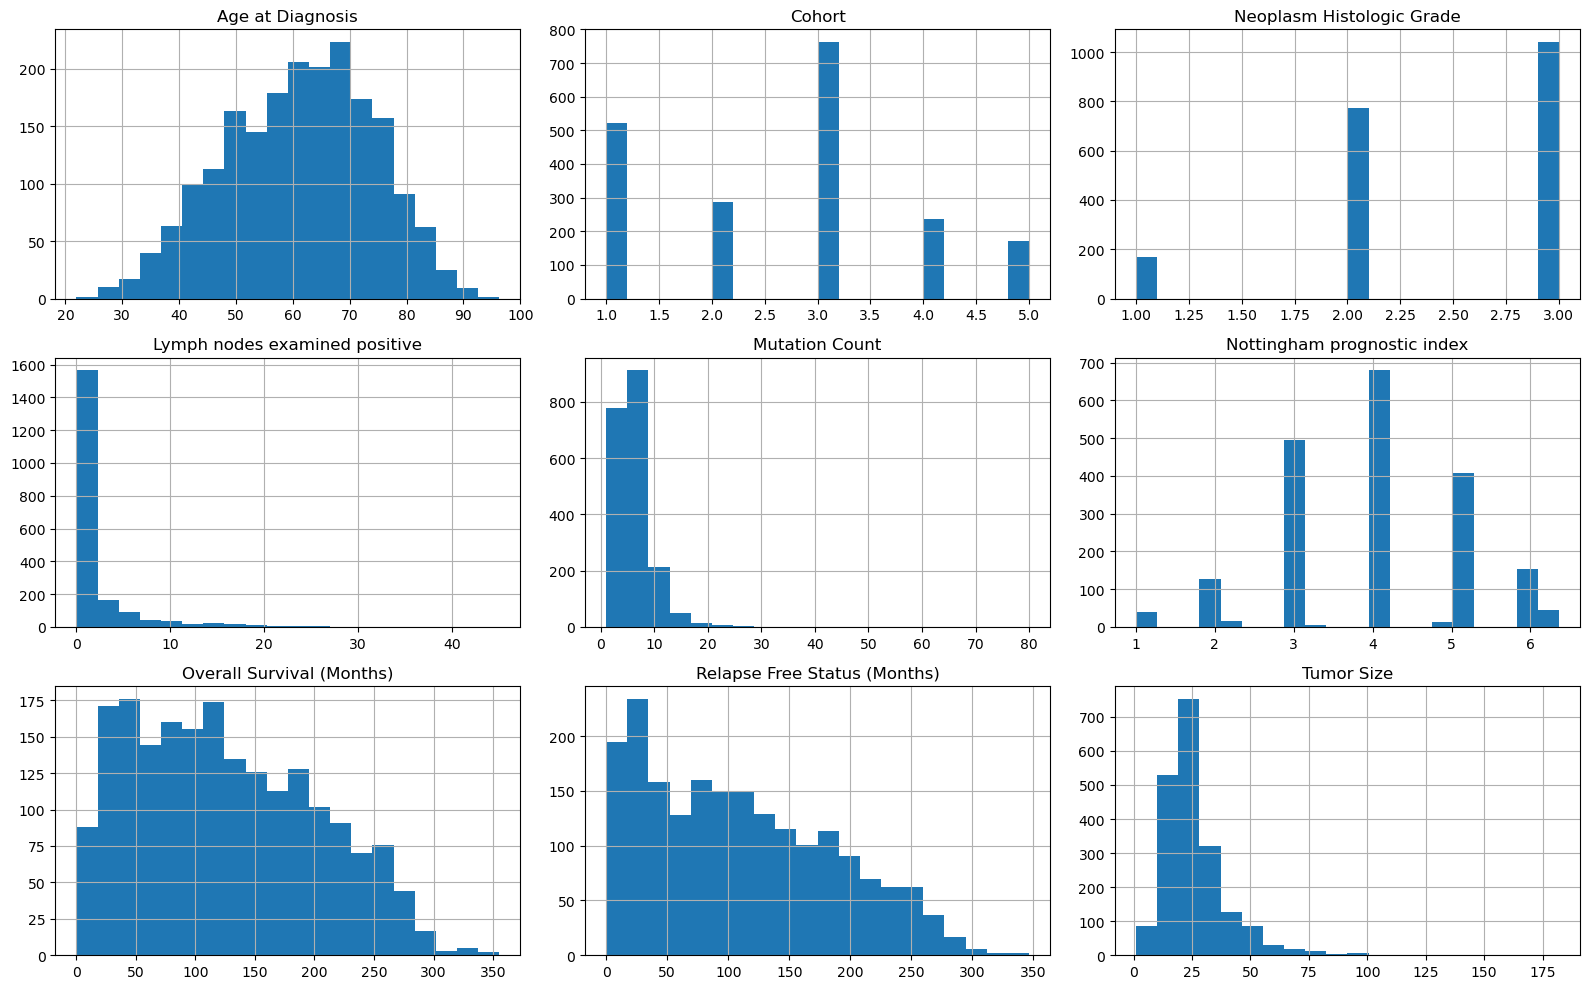

In [29]:
# visuvalization of numarical columns 
data[num_cols_for_plot].hist(figsize=(16, 10), bins=20)
plt.tight_layout()
plt.show()


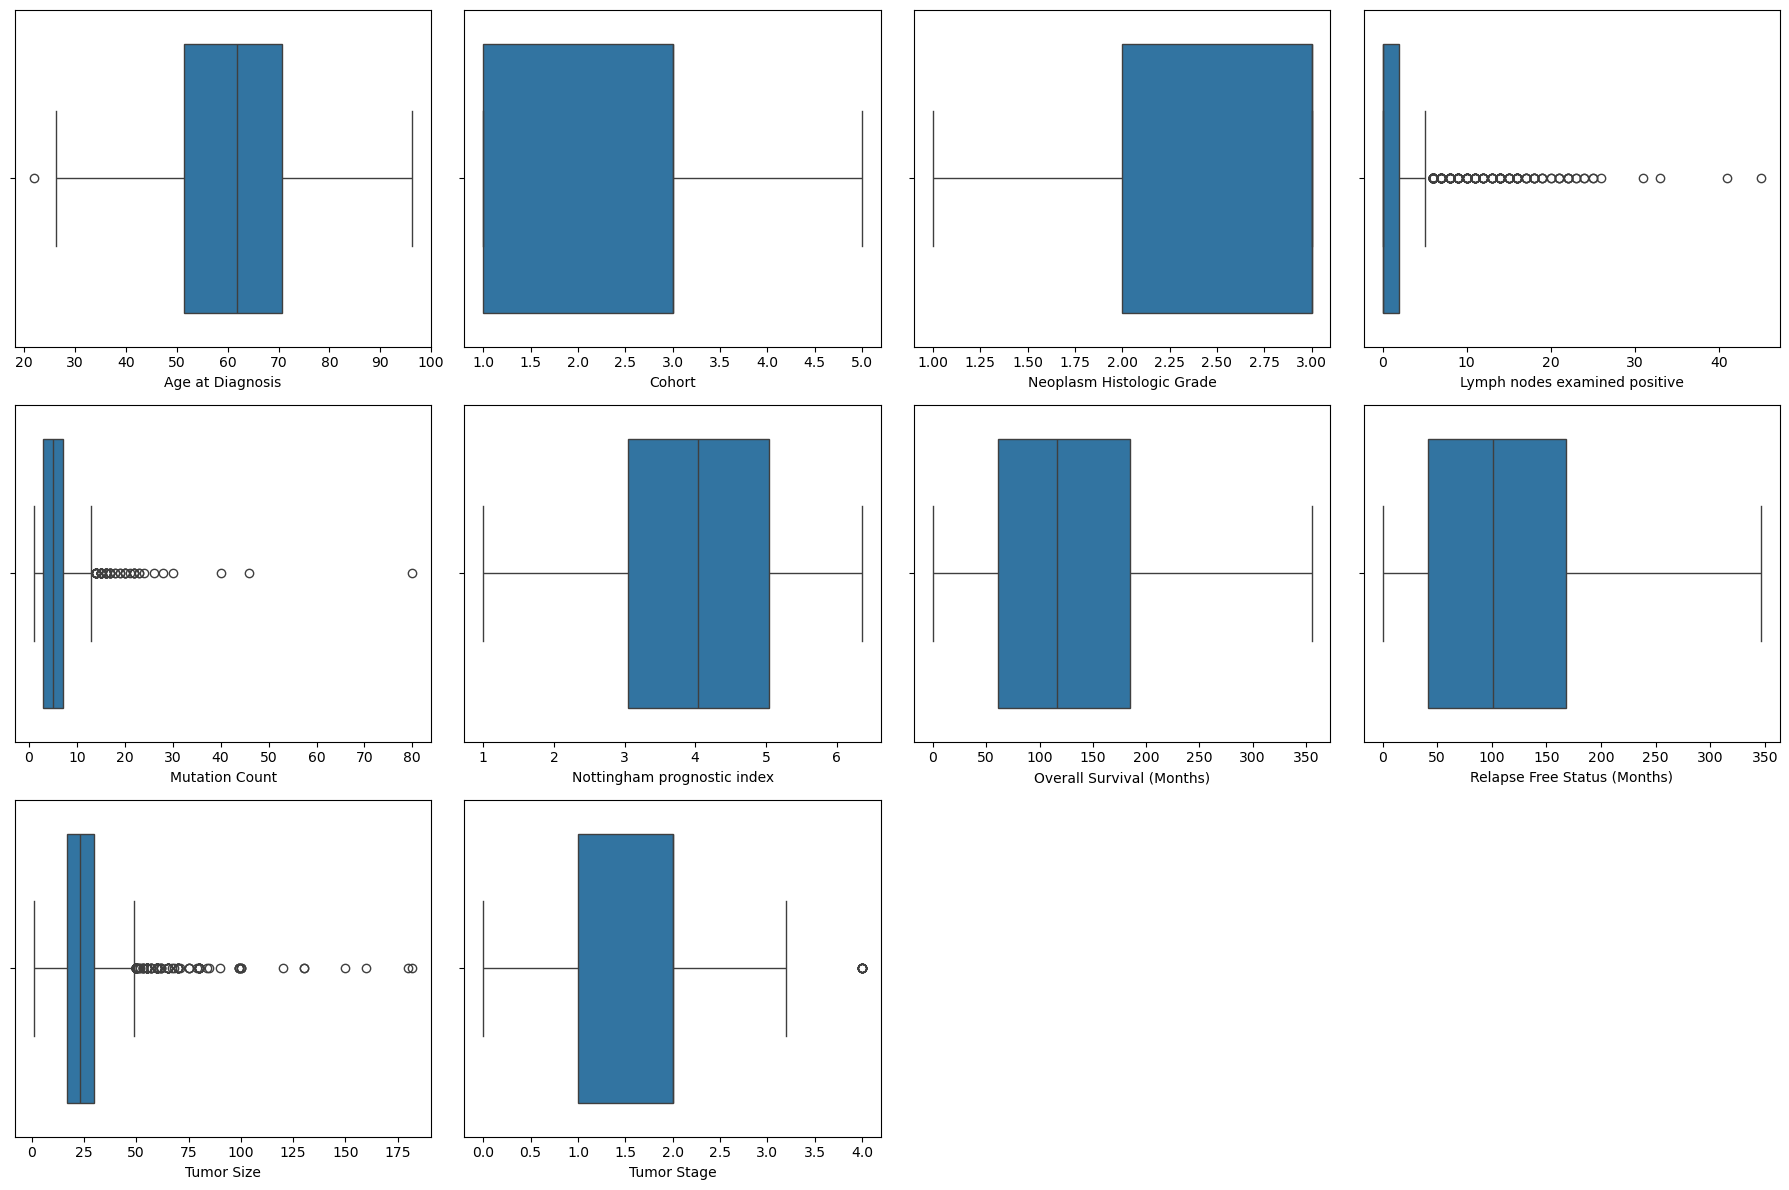

In [30]:
# outliers visuvalization
plt.figure(figsize=(18, 12))

i = 1
for col in num_cols:
    plt.subplot(3, 4, i)   # same grid style as histogram
    sns.boxplot(x=data[col])
    i = i + 1

plt.tight_layout()
plt.show()


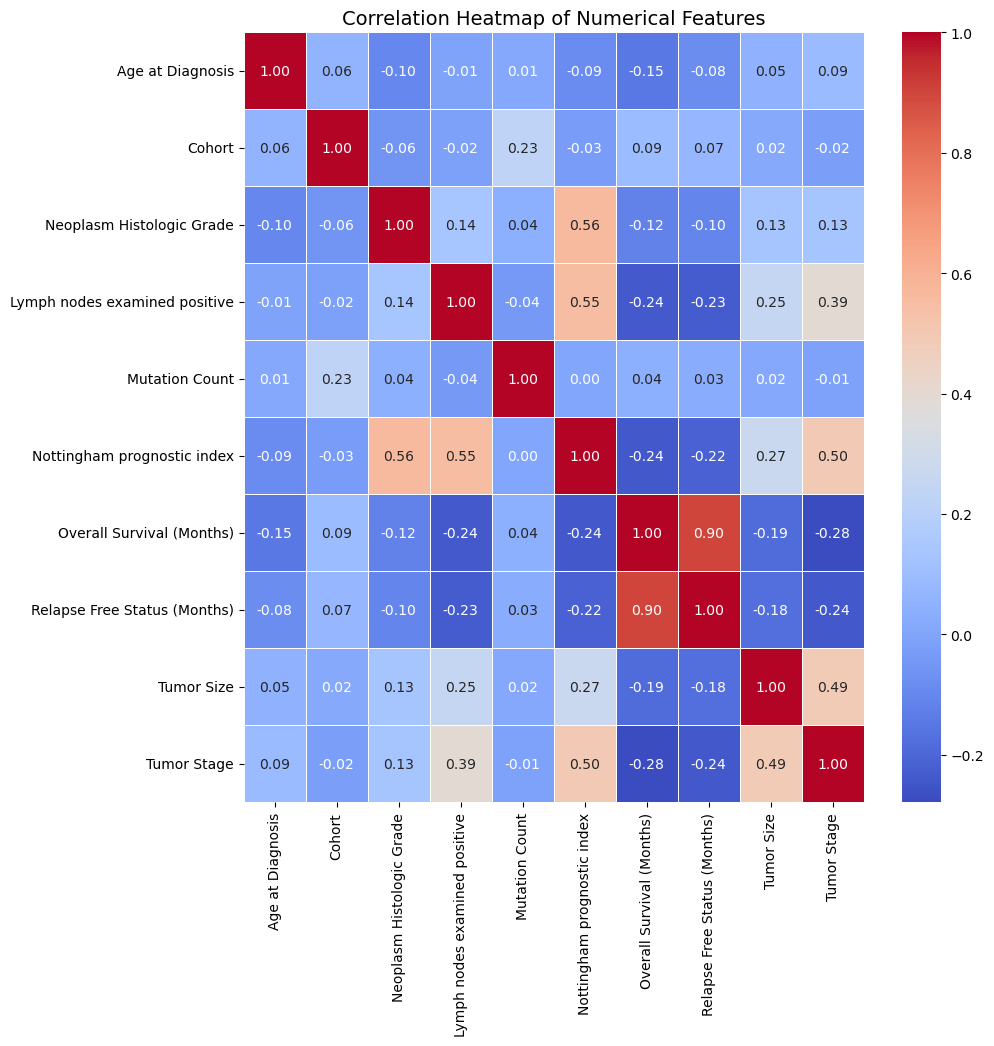

In [31]:
# correlation heatmap for numarical values
corr_matrix = data[num_cols].corr()
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix,cmap="coolwarm",annot=True,fmt=".2f",linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.show()


CATEGORICAL FEATURE DISTRIBUTION

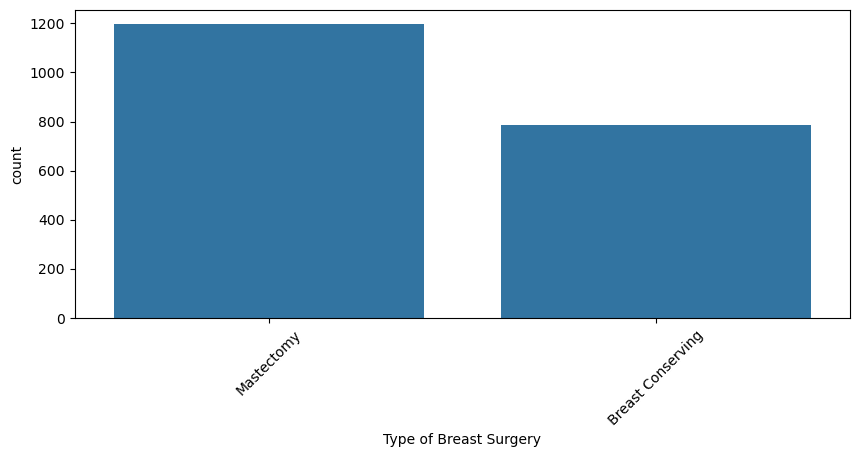

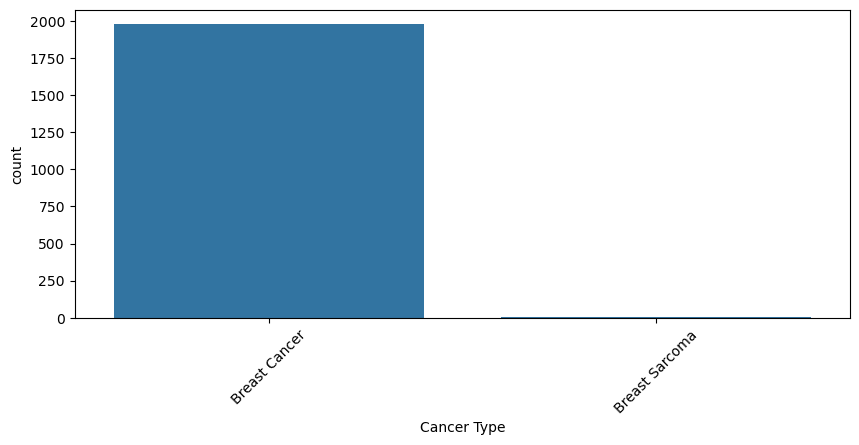

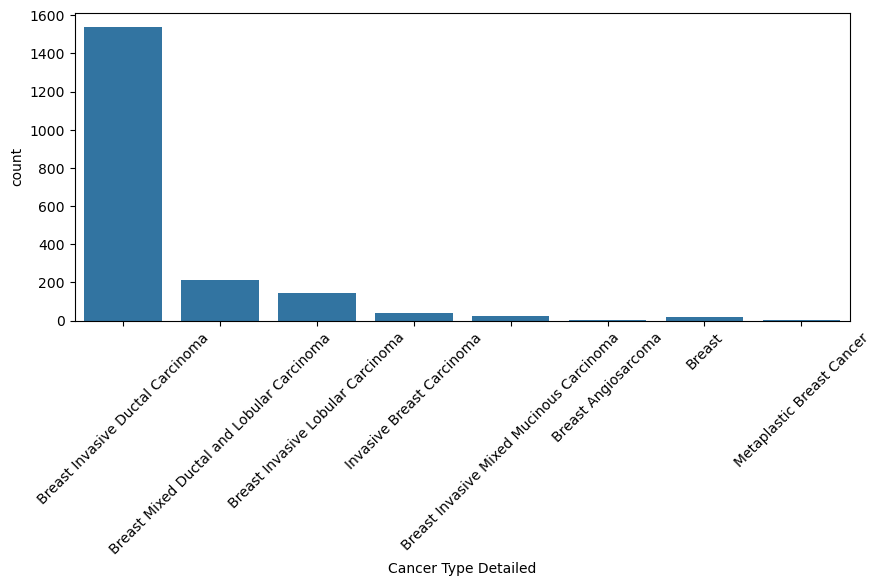

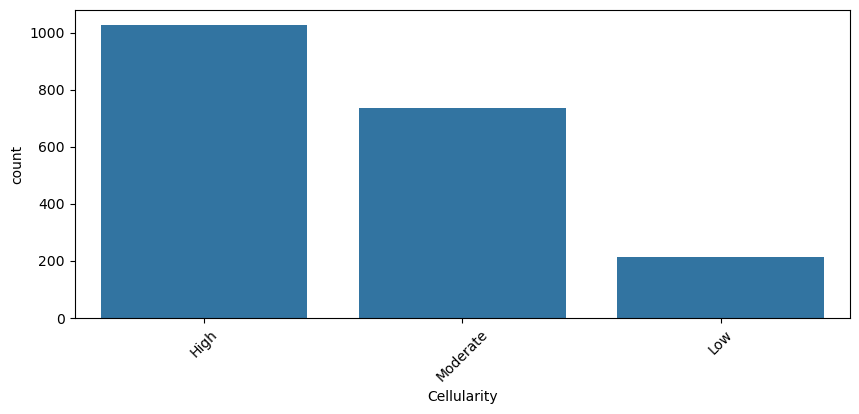

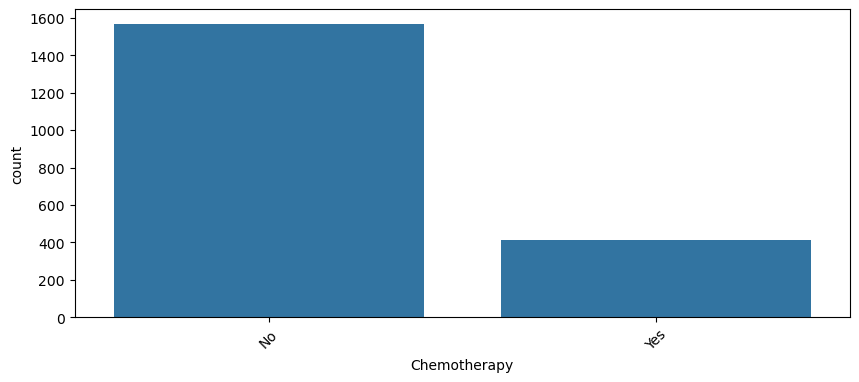

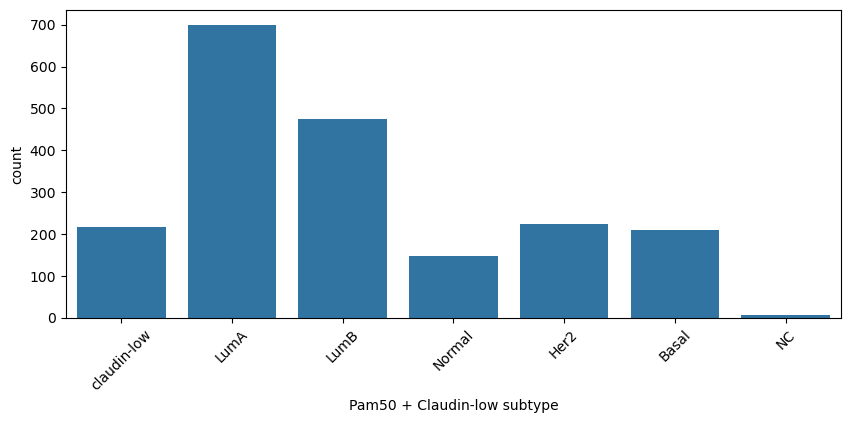

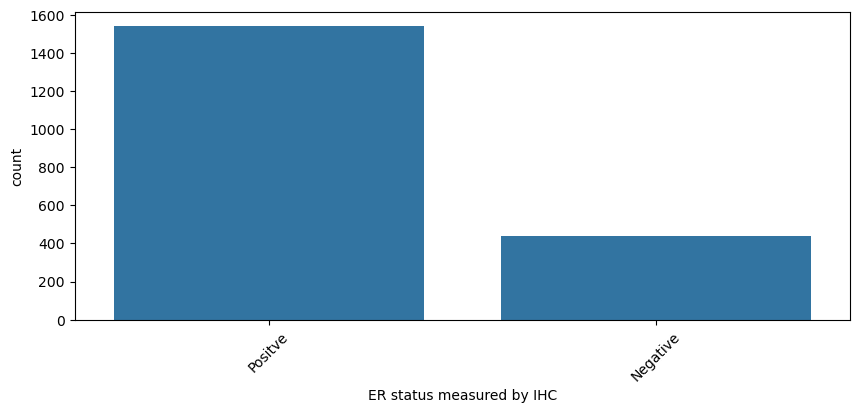

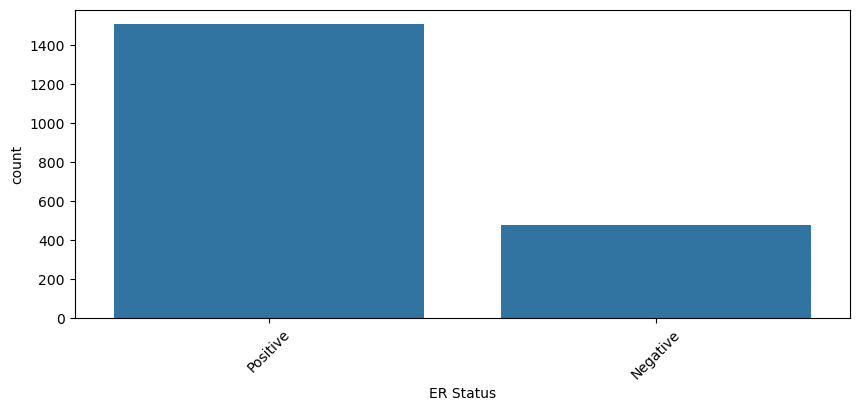

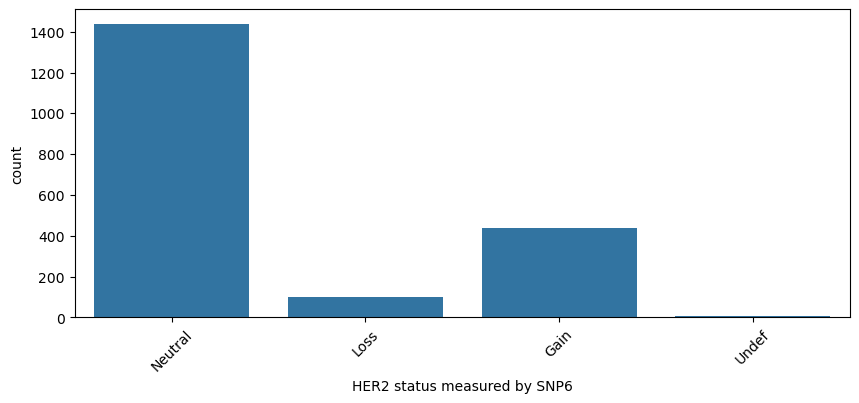

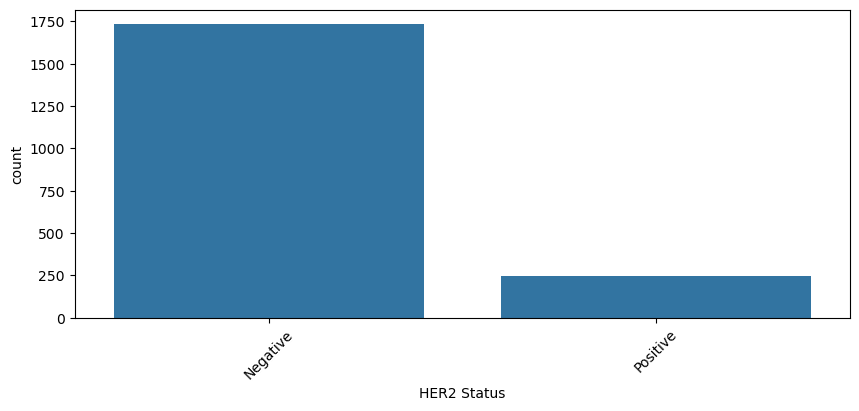

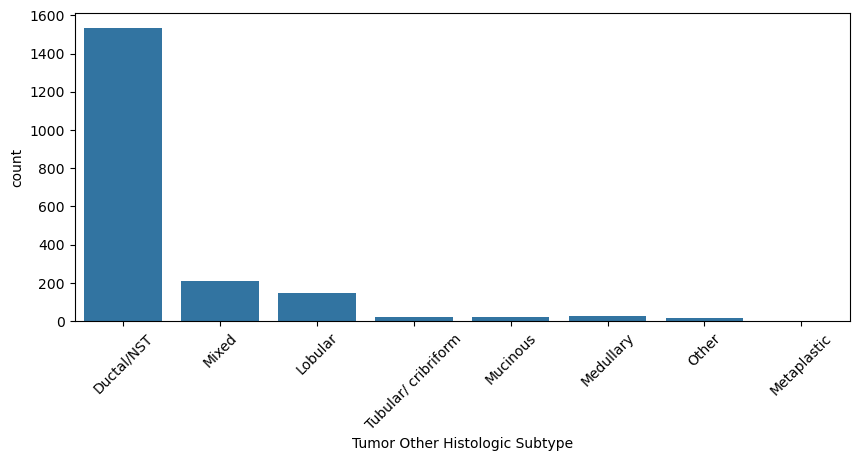

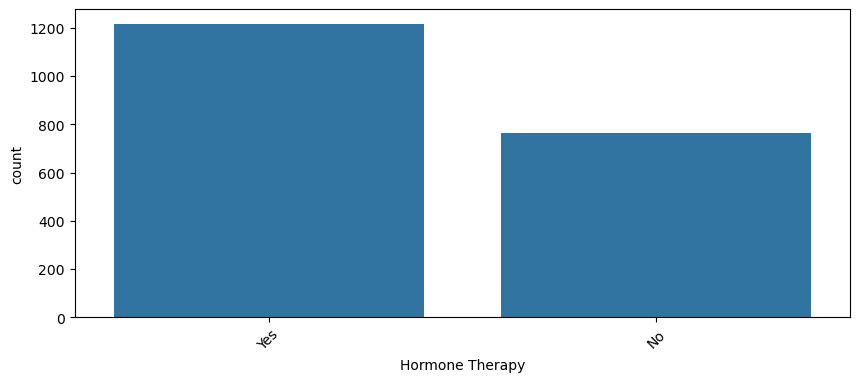

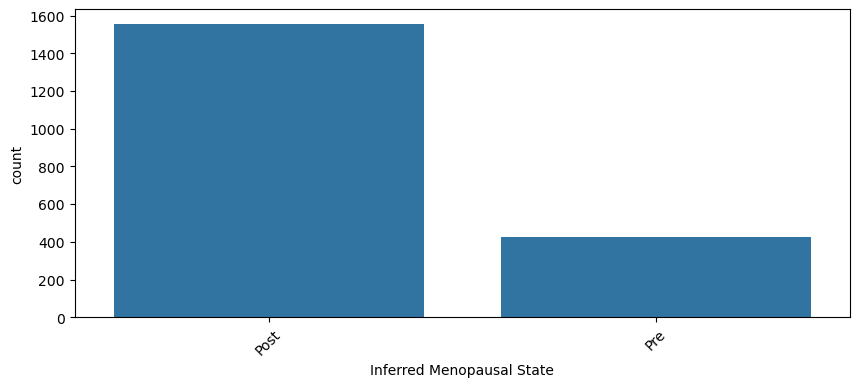

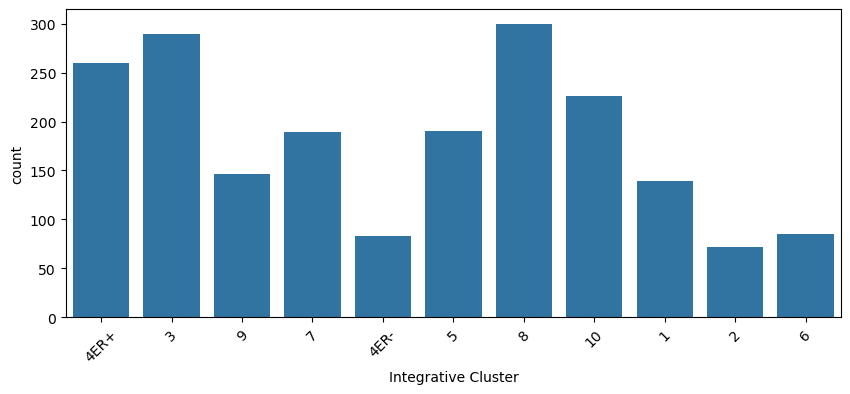

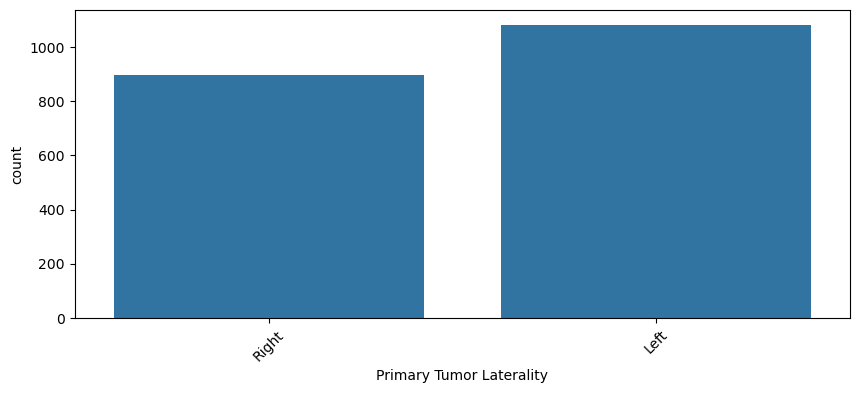

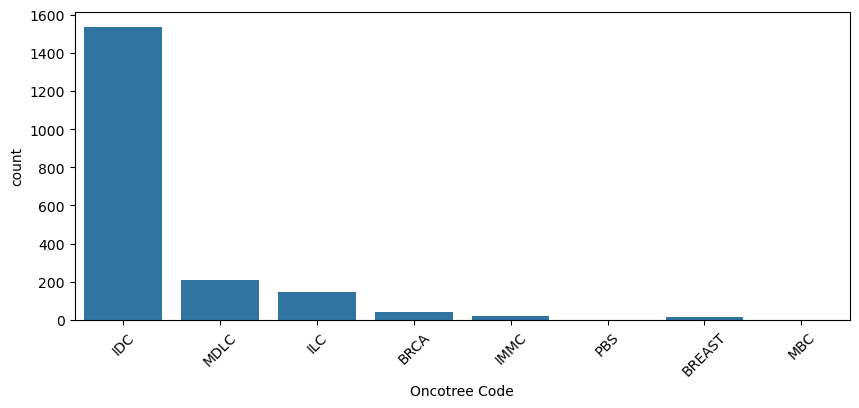

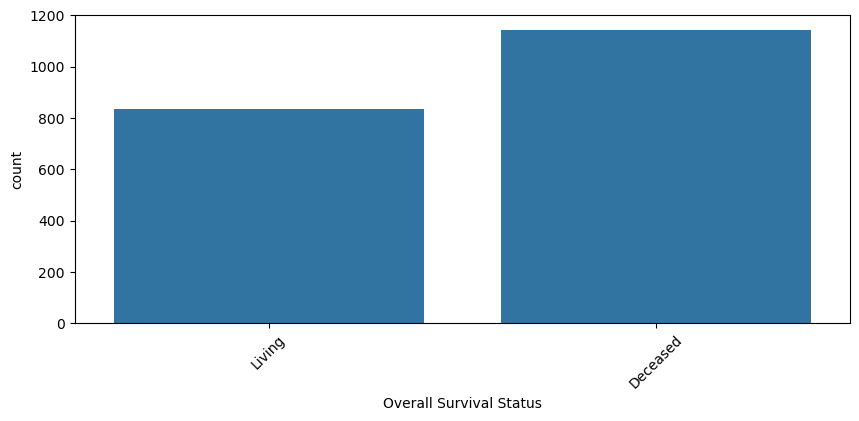

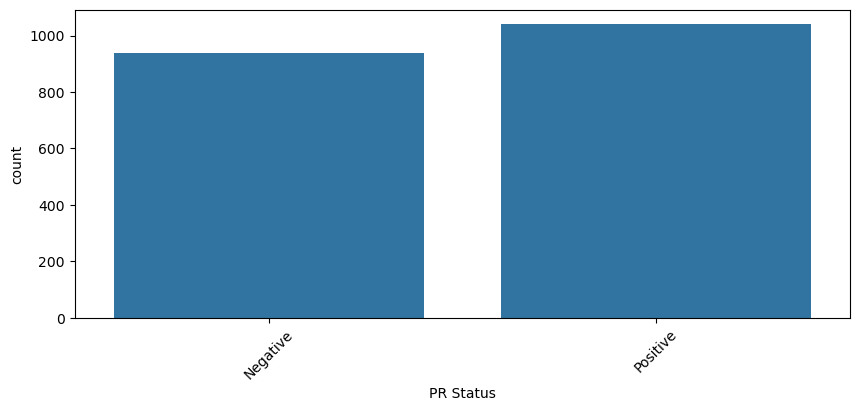

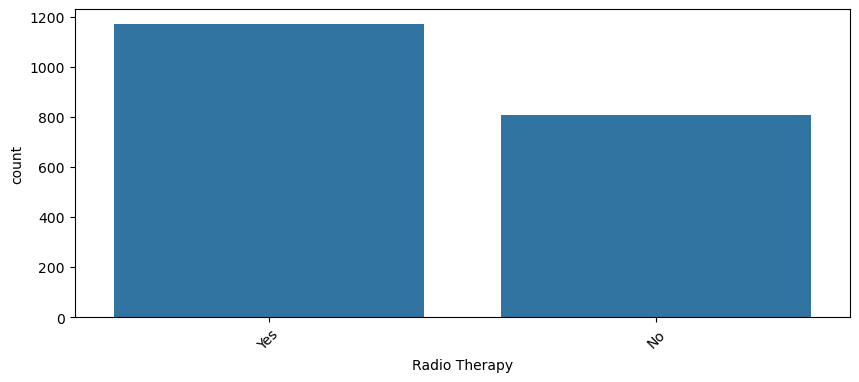

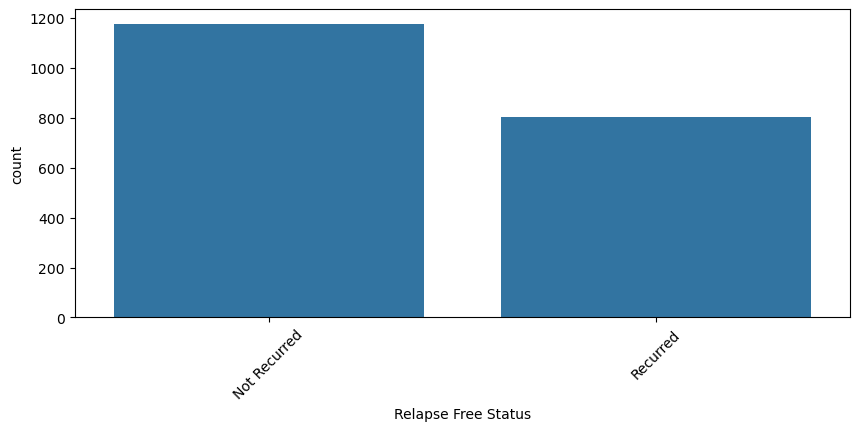

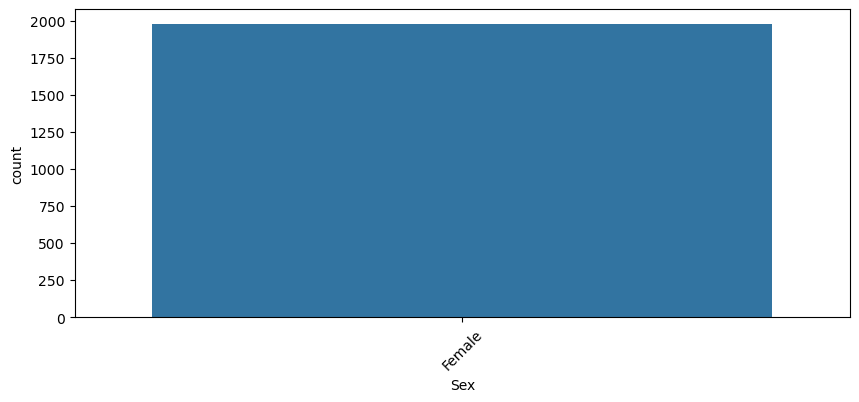

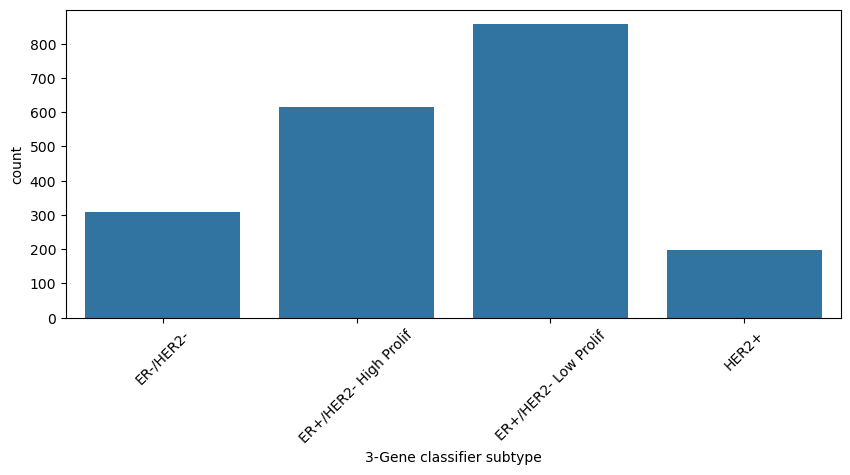

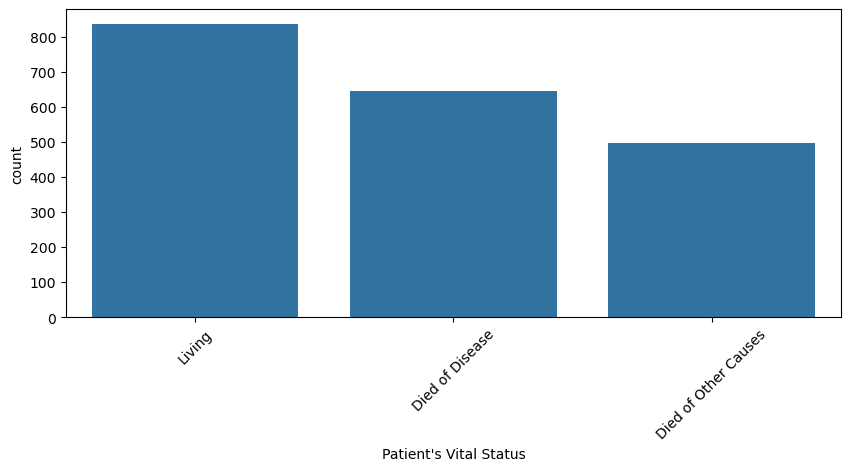

In [32]:
# visuvalization of the  categorical columns
for col in categorical_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(x=data[col])
    plt.xticks(rotation=45)
    plt.show()
    

TARGET FEATURES ANALYSIS

In [33]:
# DEFINING THE TARGET FEATURES 
data['time']= data['Overall Survival (Months)']
data['event']= data["Overall Survival Status"].map({"Living":0, "Deceased":1})

In [34]:
# cheching the distribution of the target variable
data["event"].value_counts()


event
1    1143
0     837
Name: count, dtype: int64

C:\Users\PRUSHOTHAM\AppData\Local\Temp\ipykernel_23672\2520192101.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=data, x='Age at Diagnosis', hue='Overall Survival Status', shade=True, palette='magma')


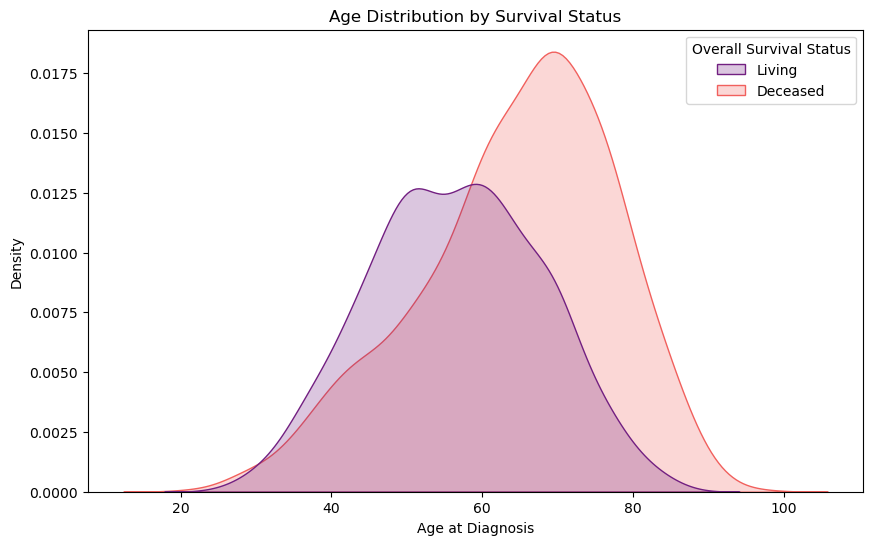

In [35]:
# Age distribution by servival status
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data, x='Age at Diagnosis', hue='Overall Survival Status', shade=True, palette='magma')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age at Diagnosis')
plt.ylabel('Density')
plt.show()

<Figure size 1000x600 with 0 Axes>

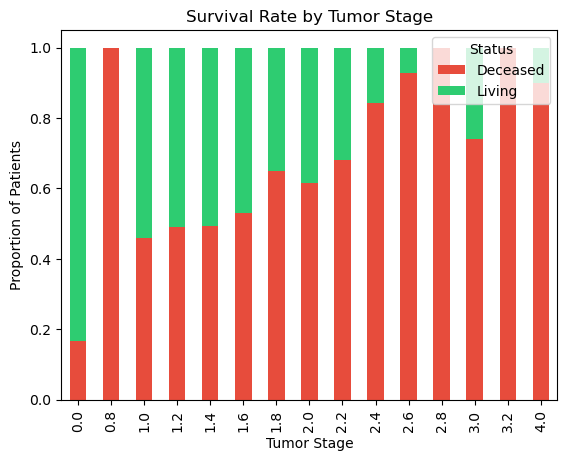

In [36]:
plt.figure(figsize=(10, 6))
stage_survival = data.groupby(['Tumor Stage', 'Overall Survival Status']).size().unstack()
stage_survival_pct = stage_survival.div(stage_survival.sum(axis=1), axis=0)

stage_survival_pct.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'])
plt.title('Survival Rate by Tumor Stage')
plt.xlabel('Tumor Stage')
plt.ylabel('Proportion of Patients')
plt.legend(title='Status', loc='upper right')
plt.show()

In [37]:
pip install lifelines

Note: you may need to restart the kernel to use updated packages.


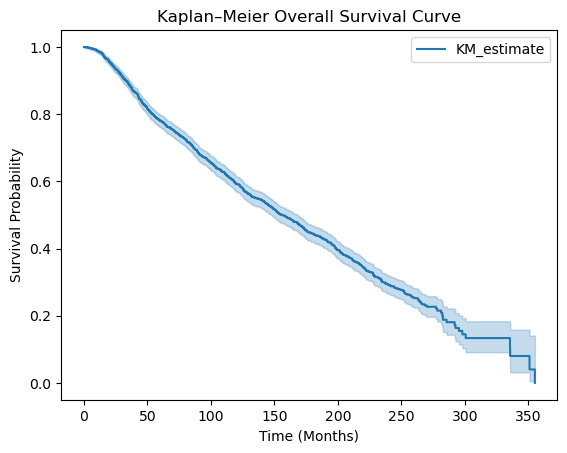

In [38]:
# implementation of kaplanmeier survival curve
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()
kmf.fit(
    durations=data["time"],
    event_observed=data["event"])
kmf.plot_survival_function()
plt.title("Kaplan–Meier Overall Survival Curve")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.show()


Observation

        Survival probability starts at 1.0 and declines steadily over time, indicating ongoing mortality throughout the study period.

        A sharper decline is observed in the early months (around 50–60 months), suggesting higher early risk.

        The median survival time is approximately 150–170 months, where survival probability reaches about 50%.

         After 250 months, the survival curve drops more rapidly, indicating increased mortality among long-term patients.

        

The widening confidence interval toward the end reflects fewer patients at risk and greater uncertainty in survival estimates.
       

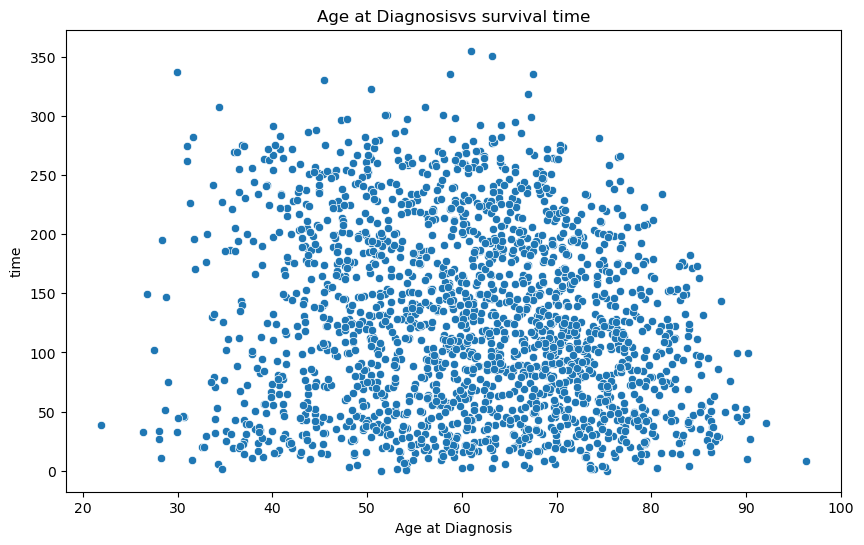

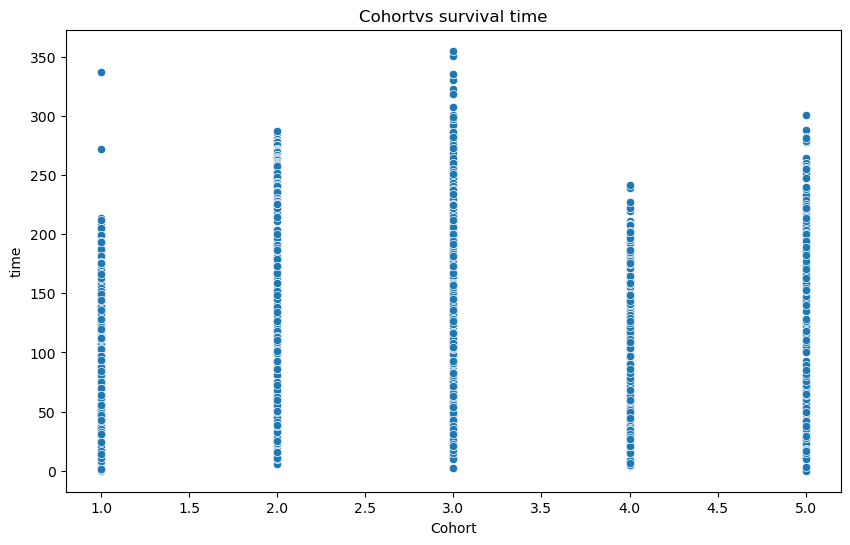

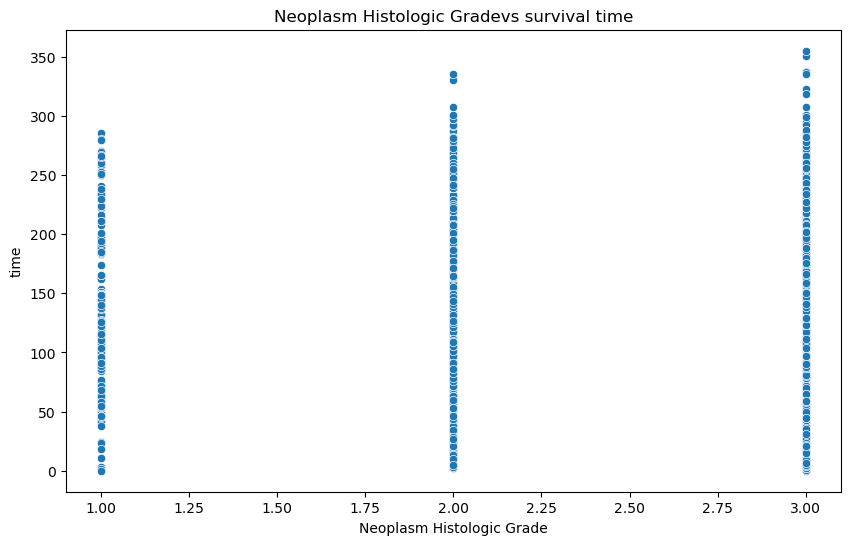

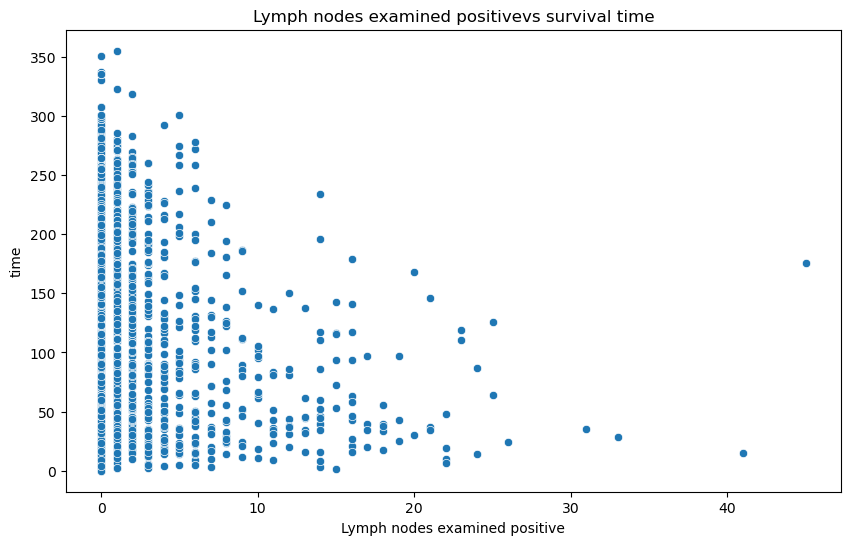

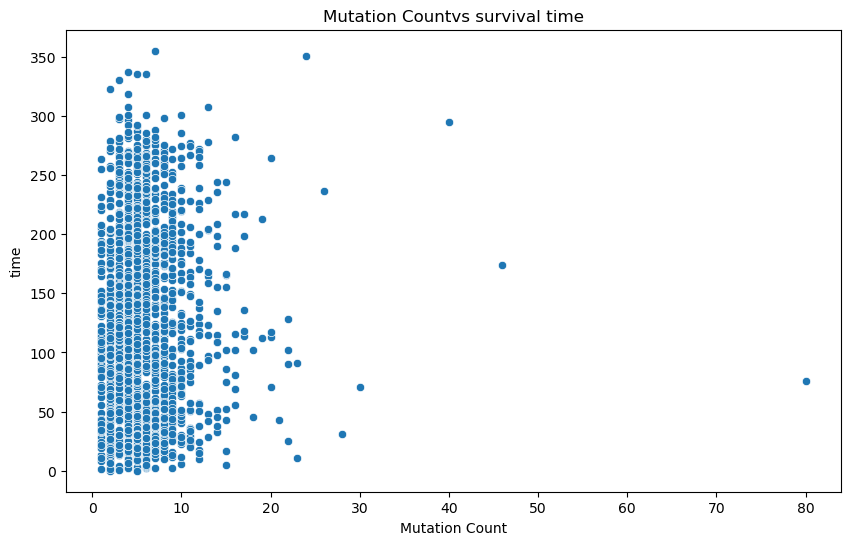

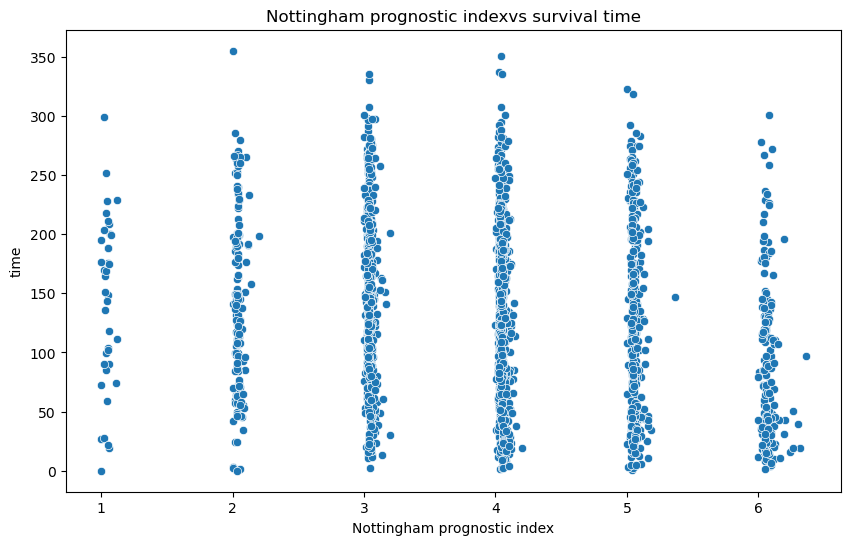

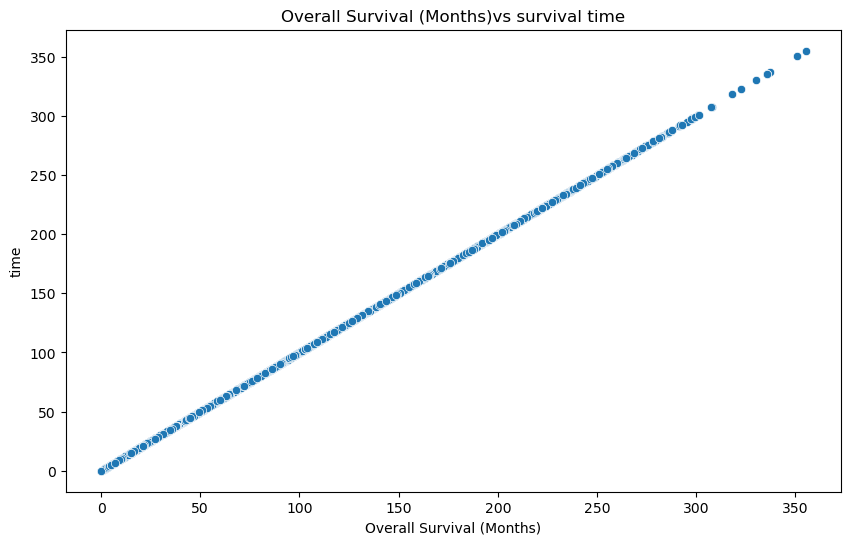

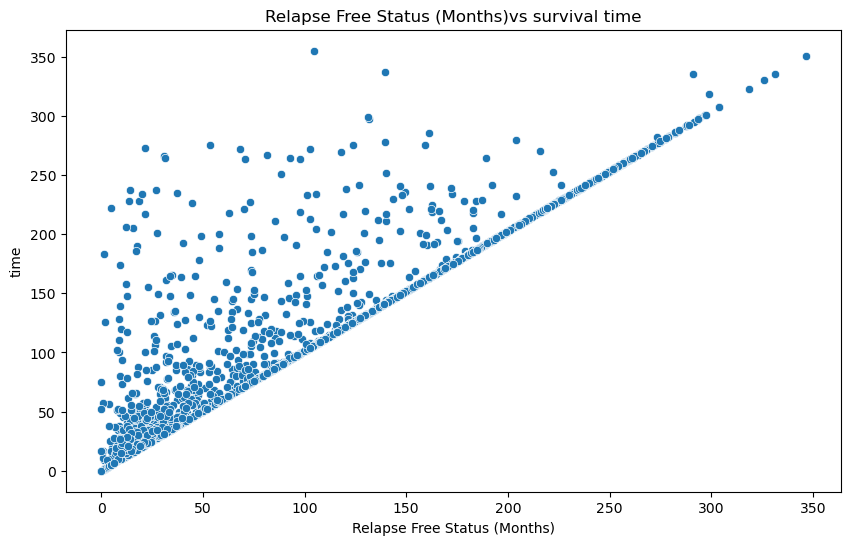

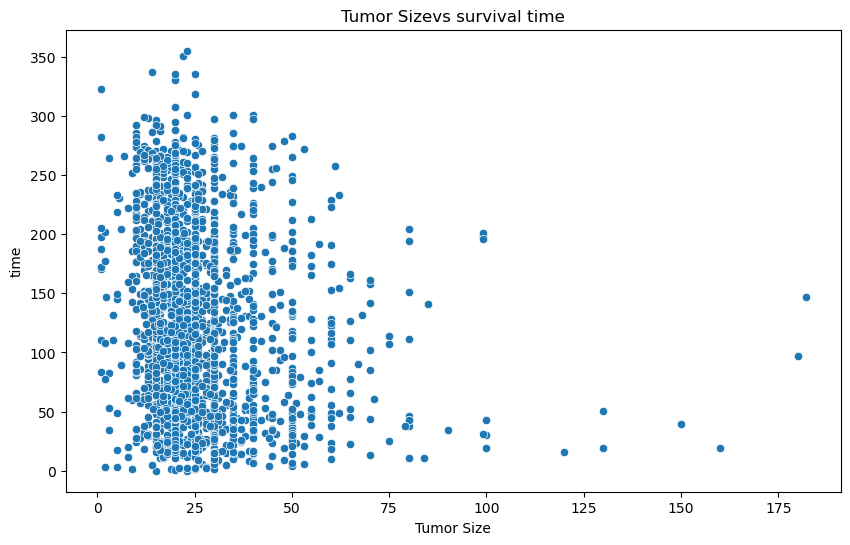

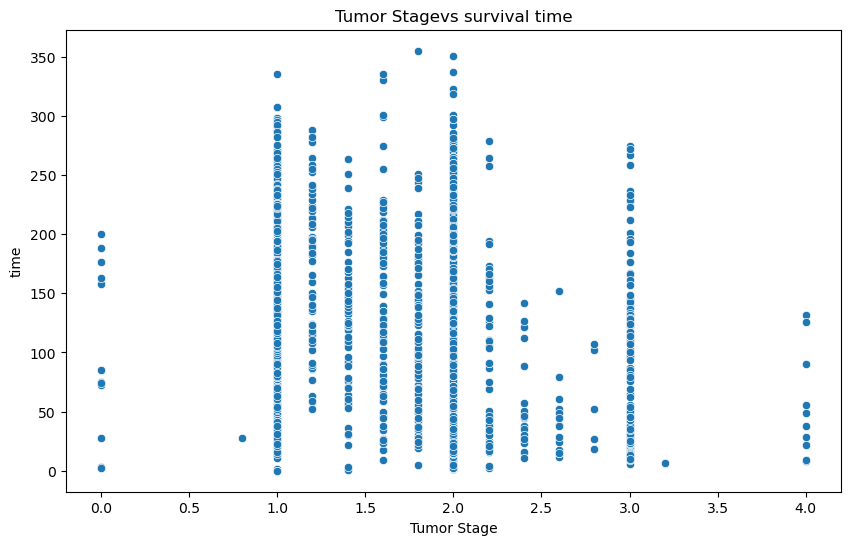

In [39]:
# scatter plots for numarical columns vs survival time
for col in num_cols:
    if col !="time":
        plt.figure(figsize=(10,6))
        sns.scatterplot(x=data[col], y=data['time'])
        plt.title(f"{col}vs survival time")
        plt.show()


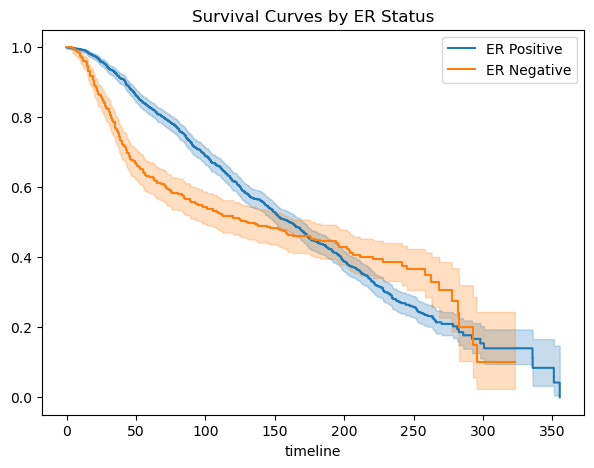

In [40]:
# survival curves by the ER status
plt.figure(figsize=(7,5))
for status in data["ER Status"].unique():
    mask = data["ER Status"] == status
    kmf.fit(data.loc[mask, "time"],data.loc[mask, "event"],label=f"ER {status}")
    kmf.plot_survival_function()
plt.title("Survival Curves by ER Status")
plt.show()


Observation

         The plot compares overall survival over time between ER-positive and ER-negative breast cancer patients.

        ER-positive patients consistently show higher survival probabilities than ER-negative patients, especially in the early and mid follow-up period.

        ER-negative patients experience a faster decline in survival during the early months, indicating more aggressive disease and poorer short-term prognosis.

        Around the 150–200 month range, the survival curves begin to converge, suggesting reduced differences in long-term survival between the two groups.

         shaded regions (confidence intervals) widen at later time points, reflecting fewer patients at risk and greater uncertainty in survival estimates

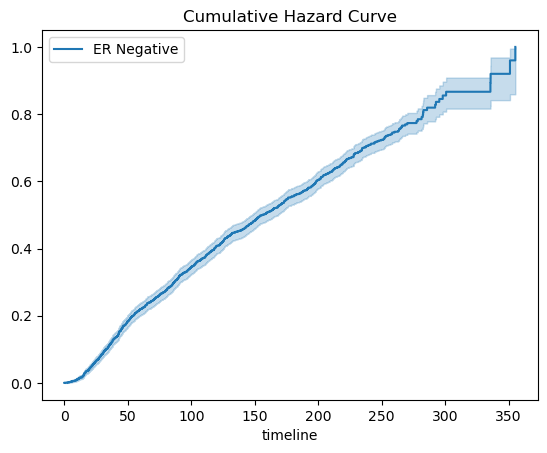

In [41]:
# cumulative hazard curve
kmf.fit(data["time"], event_observed=data["event"])
kmf.plot_cumulative_density()
plt.title("Cumulative Hazard Curve")
plt.show()


Observation

  The cumulative hazard increases steadily over time, indicating a continuous accumulation of risk for ER-negative patients.

  A steeper rise is observed in the early to mid follow-up period, suggesting higher initial risk after diagnosis.

  The curve continues to rise throughout the timeline, showing that risk does not plateau even in long-term follow-up.

 around 250–300 months, the curve becomes slightly steeper, indicating increasing hazard among long-term survivors.

The widening confidence interval toward the end reflects fewer patients at risk and greater uncertainty in hazard estimates over time
      

ENCODEING CATEGORICAL COLUMNS

In [42]:
# encodeing the categorical columns
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
num_cols = data.select_dtypes(include=["int64", "float64"]).columns
cat_cols = data.select_dtypes(include="object").columns
encoded_cat = pd.get_dummies(data[cat_cols], drop_first=True)
encoded_data = pd.concat([data[num_cols], encoded_cat], axis=1)
corr_matrix = encoded_data.corr()
print("Shape after encoding:", encoded_data.shape)

Shape after encoding: (1980, 72)


In [43]:
print(data.columns)

Index(['Age at Diagnosis', 'Type of Breast Surgery', 'Cancer Type',
       'Cancer Type Detailed', 'Cellularity', 'Chemotherapy',
       'Pam50 + Claudin-low subtype', 'Cohort', 'ER status measured by IHC',
       'ER Status', 'Neoplasm Histologic Grade',
       'HER2 status measured by SNP6', 'HER2 Status',
       'Tumor Other Histologic Subtype', 'Hormone Therapy',
       'Inferred Menopausal State', 'Integrative Cluster',
       'Primary Tumor Laterality', 'Lymph nodes examined positive',
       'Mutation Count', 'Nottingham prognostic index', 'Oncotree Code',
       'Overall Survival (Months)', 'Overall Survival Status', 'PR Status',
       'Radio Therapy', 'Relapse Free Status (Months)', 'Relapse Free Status',
       'Sex', '3-Gene classifier subtype', 'Tumor Size', 'Tumor Stage',
       'Patient's Vital Status', 'time', 'event'],
      dtype='object')


In [44]:
# dropping the unneccessary columns
cols_to_drop = [
    "Patient ID",
    "Overall Survival (Months)",   
    "Patient's Vital Status",      
    "Oncotree Code",               
    "Cohort",                      
    "ER status measured by IHC",   
    "HER2 status measured by SNP6" 
]
data = data.drop(columns=cols_to_drop, errors="ignore")


MACHINE LEARNING MODELLING

C:\Users\PRUSHOTHAM\AppData\Local\Temp\ipykernel_23672\1435311241.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Overall Survival Status', data=data, palette='viridis')


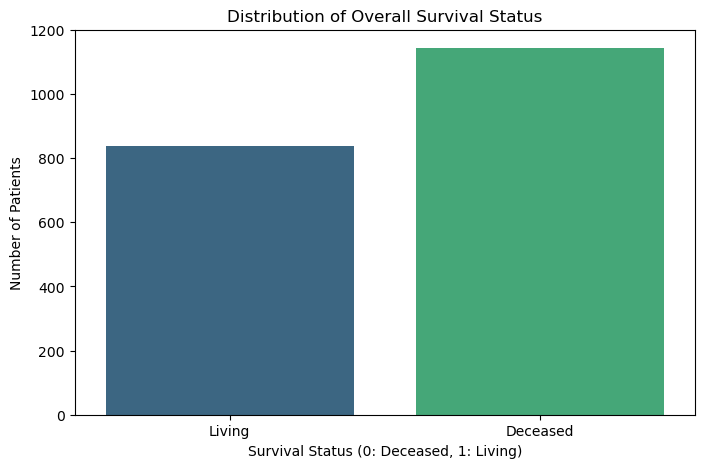

In [45]:
# Check the distribution of the target variable
plt.figure(figsize=(8, 5))
sns.countplot(x='Overall Survival Status', data=data, palette='viridis')
plt.title('Distribution of Overall Survival Status')
plt.xlabel('Survival Status (0: Deceased, 1: Living)')
plt.ylabel('Number of Patients')
plt.show()

In [46]:
# importing libraries for the modeling
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_curve, auc


In [47]:
# select relevant features
data['Age_Tumor_Interaction'] = data['Age at Diagnosis'] * data['Tumor Size']
features = ["Age at Diagnosis", "Tumor Size", "Tumor Stage", "Chemotherapy",
            "Hormone Therapy", "HER2 Status", "PR Status", "ER Status",
            "Mutation Count", "Nottingham prognostic index"]

# target varaible
target = "overall_survival_status"

In [48]:
#preparing for data modeling
x=pd.get_dummies(data[features],drop_first=True)
le = LabelEncoder()
y = le.fit_transform(data["Overall Survival Status"])

In [49]:
x.dtypes

Age at Diagnosis               float64
Tumor Size                     float64
Tumor Stage                    float64
Mutation Count                 float64
Nottingham prognostic index    float64
Chemotherapy_Yes                  bool
Hormone Therapy_Yes               bool
HER2 Status_Positive              bool
PR Status_Positive                bool
ER Status_Positive                bool
dtype: object

In [50]:
# splitting the data into train and split
x_train, x_test, y_train, y_test = train_test_split(
    x,y,          # encoded target
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [51]:
# feature scalling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [59]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

scaler = StandardScaler()
x_train_smote_scaled = scaler.fit_transform(x_train_smote)
x_test_scaled = scaler.transform(x_test)

print("Original training shape:", x_train.shape)
print("SMOTE training shape:", x_train_smote.shape)

Original training shape: (1584, 10)
SMOTE training shape: (1828, 10)


In [66]:
# logestic regrassion moel
from sklearn.linear_model import LogisticRegression

lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(x_train_smote_scaled, y_train_smote)

y_pred_lr = lr_smote.predict(x_test_scaled)
y_prob_lr = lr_smote.predict_proba(x_test_scaled)[:, 1]

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.6616161616161617
ROC-AUC: 0.6992913735847083
              precision    recall  f1-score   support

           0       0.74      0.64      0.69       229
           1       0.58      0.69      0.63       167

    accuracy                           0.66       396
   macro avg       0.66      0.67      0.66       396
weighted avg       0.67      0.66      0.66       396



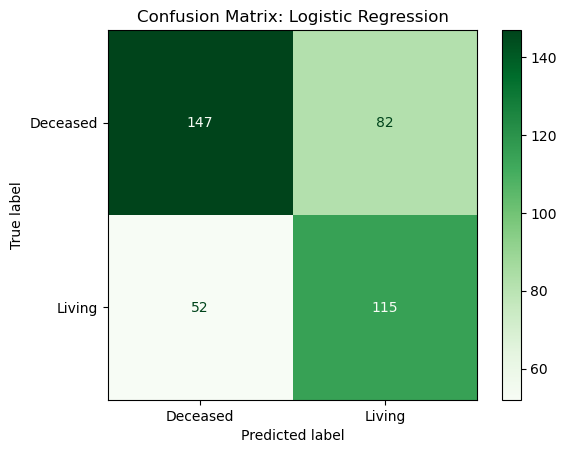

In [67]:
#confusion matrix for the Logistic regrassion
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=le.classes_)
disp_lr.plot(cmap='Greens')
plt.title("Confusion Matrix: Logistic Regression")
plt.show()

In [74]:
#Random Forest Classifier model

rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)
y_prob_rf = rf_model.predict_proba(x_test)[:, 1]

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.6590909090909091
ROC-AUC: 0.7144575477865229
              precision    recall  f1-score   support

           0       0.71      0.69      0.70       229
           1       0.59      0.61      0.60       167

    accuracy                           0.66       396
   macro avg       0.65      0.65      0.65       396
weighted avg       0.66      0.66      0.66       396



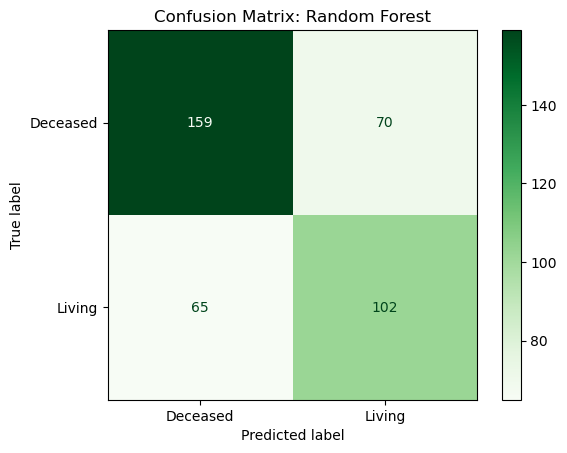

In [75]:
#confussion maatrix for the Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le.classes_)
disp_rf.plot(cmap='Greens')
plt.title("Confusion Matrix: Random Forest")
plt.show()

In [76]:
# XGBoost Classifier Model
xgb_smote = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_smote.fit(x_train_smote, y_train_smote)

y_pred_xgb = xgb_smote.predict(x_test)
y_prob_xgb = xgb_smote.predict_proba(x_test)[:, 1]
print("XGBoost Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))


XGBoost Results
Accuracy: 0.6717
ROC-AUC: 0.7268

Classification Report:
              precision    recall  f1-score   support

    Deceased       0.72      0.71      0.71       229
      Living       0.61      0.62      0.61       167

    accuracy                           0.67       396
   macro avg       0.66      0.66      0.66       396
weighted avg       0.67      0.67      0.67       396



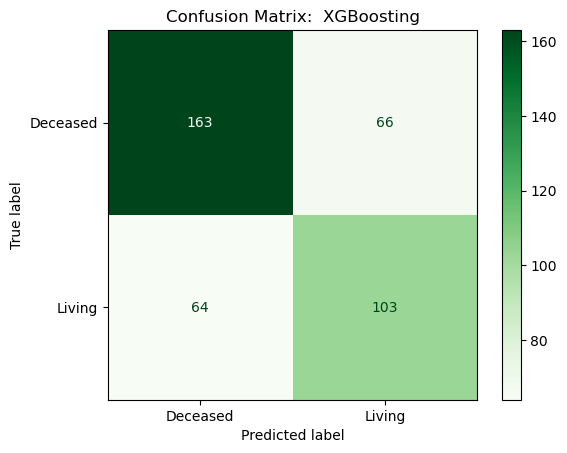

In [77]:
#confusion matrix for XGBoost
cm_gb = confusion_matrix(y_test, y_pred_xgb)
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=le.classes_)
disp_gb.plot(cmap='Greens')
plt.title("Confusion Matrix:  XGBoosting")
plt.show()

In [78]:
# support Vector Machine Model
svm_smote = SVC(probability=True, random_state=42)
svm_smote.fit(x_train_smote_scaled, y_train_smote)

y_pred_svm = svm_smote.predict(x_test_scaled)
y_prob_svm = svm_smote.predict_proba(x_test_scaled)[:, 1]

print("SVM Results")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))
print(classification_report(y_test, y_pred_svm))

SVM Results
Accuracy: 0.6616161616161617
ROC-AUC: 0.7022592369845462
              precision    recall  f1-score   support

           0       0.73      0.66      0.69       229
           1       0.59      0.66      0.62       167

    accuracy                           0.66       396
   macro avg       0.66      0.66      0.66       396
weighted avg       0.67      0.66      0.66       396



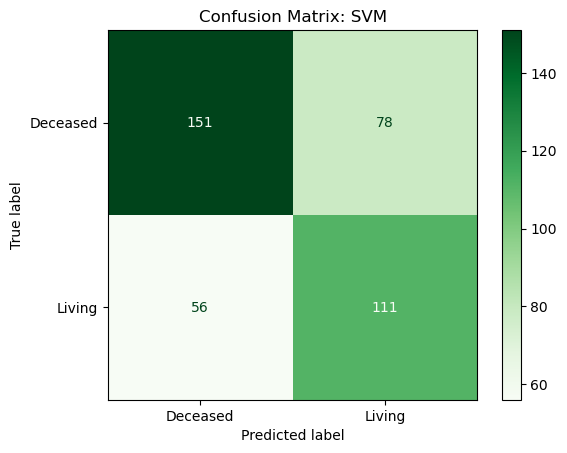

In [79]:
# confusion matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=le.classes_)
disp_svm.plot(cmap='Greens')
plt.title("Confusion Matrix: SVM")
plt.show()

In [80]:
# Dession Tree Classifier Model
dt_smote = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_smote.fit(x_train_smote, y_train_smote)

y_pred_dt = dt_smote.predict(x_test)
y_prob_dt = dt_smote.predict_proba(x_test)[:, 1]

print("Decision Tree Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_dt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results
Accuracy: 0.6061
ROC-AUC: 0.6695

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.62      0.65       229
           1       0.53      0.58      0.55       167

    accuracy                           0.61       396
   macro avg       0.60      0.60      0.60       396
weighted avg       0.61      0.61      0.61       396



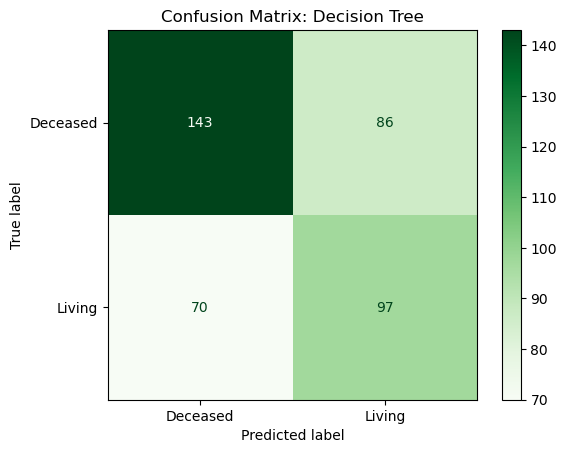

In [81]:
# Confusion Matrix for Dession Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=le.classes_)
disp_dt.plot(cmap='Greens')
plt.title("Confusion Matrix: Decision Tree")
plt.show()

In [82]:
# declaring the model to plot ROC curves
# 1. Random Forest
best_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
best_rf.fit(x_train, y_train)

# 2. Gradient Boosting
best_gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
best_gb.fit(x_train, y_train)

# 3. Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
dt_model.fit(x_train, y_train)

# 4. Logistic Regression (Use Scaled Data)
best_lr = LogisticRegression(max_iter=1000, class_weight='balanced')
best_lr.fit(x_train_scaled, y_train)

# 5. SVM (Use Scaled Data)
best_svm = SVC(probability=True, class_weight='balanced')
best_svm.fit(x_train_scaled, y_train)

SVC(class_weight='balanced', probability=True)

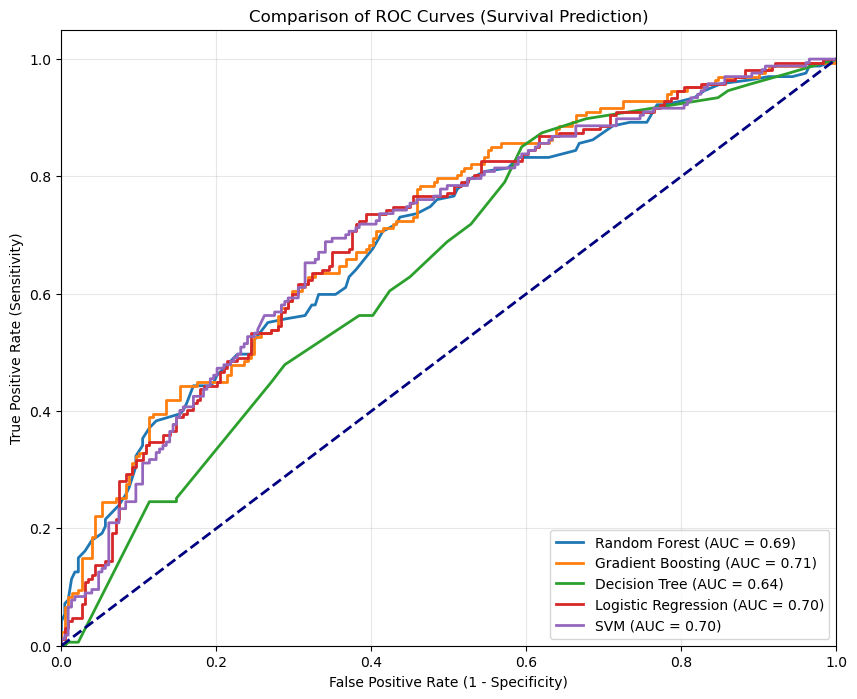

In [84]:
# plotting ROC curves for all models
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Prepare the plot
plt.figure(figsize=(10, 8))

# 2. List of models and their respective test data (Scaled vs Non-Scaled)
# Ensure you use the probability outputs ([:, 1]) for ROC
model_data = [
    ("Random Forest", best_rf, x_test),
    ("Gradient Boosting", best_gb, x_test),
    ("Decision Tree", dt_model, x_test),
    ("Logistic Regression", best_lr, x_test_scaled),
    ("SVM", best_svm, x_test_scaled)
]

for name, model, test_x in model_data:
    # Get probabilities for the positive class
    probs = model.predict_proba(test_x)[:, 1]
    
    # Compute False Positive Rate and True Positive Rate
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    
    # Plot the curve
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

# 3. Plot formatting
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal line (random guessing)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Comparison of ROC Curves (Survival Prediction)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Observation

         Logistic Regression , Random Forest and XGBoost perform the best, both achieving an AUC of 0.71, indicating good discriminatory ability.

         SVM shows slightly lower performance with an AUC of 0.70, still performing better than random guessing but below the top models.

        Decision Tree achieves moderate performance with an AUC of 0.68, suggesting limited generalization compared to ensemble models.

        As the recall is high for the Random Forrest we can consider the Random Forest is the best model

